# COMP24112 Summative Exercise (30 Marks)
# Linear Regression and Image Classification by Neural Networks

In this lab exercise, you will build linear models to predict diabetes progression (14 marks) and build neural networks to classify FashionMNIST images (16 marks). To prepare for this lab exercise, you will
* Get familiar with relevant lecture content.
* Get familiar with how to build multilayer perceptron (MLP) for classification using the scikit learn tutorial (https://scikit-learn.org/stable/modules/neural_networks_supervised.html#).
* Get familiar with basic scikit-learn tools for [data splitting](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html) and [cross validation](https://scikit-learn.org/stable/modules/cross_validation.html), used for setting machine learning experiments.

You will submit a notebook file, a pdf report, and a trained model. You will be marked for implementation, design, result and analysis. Your code should be easy to read and your report should be concise (max 600 words). It is strongly recommended that you use a LaTeX editor, such as [Overleaf](https://www.overleaf.com/), to write your report. Handwritten reports will not be accepted.

Please note your notebook should take no more than 10 minutes to run on a Google Colab instance. **Marks may be dropped for inefficient and unreadable code.**

Note: This coursework is an individual assignment, for which you are NOT permitted to collaborate
with other students, and must NOT use any generative agents (such as ChatGPT) to generate
answers or code. Any of these will be considered as academic malpractice.


## 1. Linear Regression (14 marks)
### 1.1 Dataset and Experiment Preparation

The provided "Diabetes Dataset" contains physiological and clinical measurements collected from patients to study diabetes progression. It includes 442 instances with 10 standardised numerical features, including attributes such as age, sex, body mass index (BMI), blood pressure, and several blood serum measurements. You will predict the target variable that represents a continuous measure of disease progression one year after baseline, making this a regression task. Example code for importing the data and observing statistics is provided below.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import sklearn.model_selection
from sklearn.datasets import load_diabetes

notebook_start_time = time.time()

diabetes = load_diabetes(as_frame=True)
diabetes_data_full = diabetes.frame.copy()

# Display a sample of the original dataset
diabetes_data_full.head()



,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [2]:
# Generate and display summary statistics of the dataset to check key attributes such as sample count, mean, and standard deviation of numerical features
diabetes_data_full.describe()



,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
count,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,442.000000
mean,-2.511817e-19,1.230790e-17,-2.245564e-16,-4.797570e-17,-1.381499e-17,3.918434e-17,-5.777179e-18,-9.042540e-18,9.293722e-17,1.130318e-17,152.133484
std,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,77.093005
min,-1.072256e-01,-4.464164e-02,-9.027530e-02,-1.123988e-01,-1.267807e-01,-1.156131e-01,-1.023071e-01,-7.639450e-02,-1.260971e-01,-1.377672e-01,25.000000
25%,-3.729927e-02,-4.464164e-02,-3.422907e-02,-3.665608e-02,-3.424784e-02,-3.035840e-02,-3.511716e-02,-3.949338e-02,-3.324559e-02,-3.317903e-02,87.000000
50%,5.383060e-03,-4.464164e-02,-7.283766e-03,-5.670422e-03,-4.320866e-03,-3.819065e-03,-6.584468e-03,-2.592262e-03,-1.947171e-03,-1.077698e-03,140.500000
75%,3.807591e-02,5.068012e-02,3.124802e-02,3.564379e-02,2.835801e-02,2.984439e-02,2.931150e-02,3.430886e-02,3.243232e-02,2.791705e-02,211.500000
max,1.107267e-01,5.068012e-02,1.705552e-01,1.320436e-01,1.539137e-01,1.987880e-01,1.811791e-01,1.852344e-01,1.335973e-01,1.356118e-01,346.000000


In [3]:
# Separate the dataset into input features and regression target
regression_features_df = diabetes_data_full.drop(columns=['target'])
regression_features = regression_features_df.to_numpy()
regression_targets = diabetes_data_full['target'].to_numpy()

# Display a sample of the processed dataset
pd.concat([regression_features_df.head(), diabetes_data_full[['target']].head()], axis=1)



,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0



### 1.2 Model Training and Testing (4 marks)
**On Model and Training Objective Function**: Train a linear model by minimising the Huber loss. Specifically, given a set of $N$ training samples $\{(\mathbf{x}_i, y_i)\}_{i=1}^N$, where $\mathbf{x}_i$ is the feature vector and $y_i \in \mathcal{R}$ is the real-valued scalar output for the $i$-th training sample, the training objective function to minimise is
$$O =   \frac{1}{N}\sum^N_{i=1} L_{\delta}\left(y_i, \mathbf{w}^T\mathbf{x}_i + w_0 \right).$$
Here, $\mathbf{w}$ is the column weight vector of the linear model, $w_0$ is the bias parameter of the model, and $L_{\delta}(\cdot, \cdot)$ is the huber loss function with a hyperparameter $\delta>0$, which is defined as
$$L_{\delta}(y, f(\mathbf{x})) = \left\{\begin{array}{l l }
   \frac{1}{2}(y-f(\mathbf{x}))^2,  & \text{if} |y-f(\mathbf{x})|\leq \delta, \\
    \delta \left(|y-f(\mathbf{x})| -\frac{1}{2}\delta\right), & \text{otherwise}.
\end{array}\right.$$
This loss mixes squared loss and absolute loss.

**Instruction for Implementing `linear_gd_train`**: Complete the implementation of the training function `linear_gd_train` below, which trains a linear model by minimising the above training loss using gradient descent. The function should return the trained model weights and the corresponding objective function value per iteration. In addition to the training data, the function should take the hyperparameter $\delta$, learning rate $\eta$, and the number of iterations $N_{max}$ as arguments. A reasonably good setting of these parameters has been provided below. 

**Notes**: Scikit-learn and PyTorch are NOT allowed for implementing `linear_gd_train`. You should avoid using `for` loops in your implementation of the objective function or weight update, and instead use built-in numpy operations for efficiency.

In [4]:
def linear_gd_train(data, labels, delta=10.0, n_iters=200, learning_rate=0.01, random_state=None):
    """
    Train a linear regression model using gradient descent on Huber loss.

    data: training data of shape (N, D)
    labels: training targets of shape (N,)
    delta: Huber threshold
    n_iters: number of iterations
    learning_rate: gradient descent step size
    random_state: seed for reproducibility

    Returns:
        cost_all: array of cost values per iteration
        w_all: array of weights per iteration
    """
    rng = np.random.default_rng(seed=random_state)

    # add bias column
    X_tilde = np.hstack([np.ones((data.shape[0], 1)), data])
    y = labels.copy()

    # initialise weights
    w = rng.normal(loc=0.0, scale=0.01, size=X_tilde.shape[1])

    # storage
    w_all = np.zeros((n_iters, X_tilde.shape[1]))
    cost_all = np.zeros(n_iters)

    for i in range(n_iters):
        y_pred = X_tilde @ w
        errors = y_pred - y
        abs_errors = np.abs(errors)

        # Huber loss
        quadratic_mask = abs_errors <= delta
        linear_mask = ~quadratic_mask

        loss = np.zeros_like(errors)
        loss[quadratic_mask] = 0.5 * errors[quadratic_mask] ** 2
        loss[linear_mask] = delta * (abs_errors[linear_mask] - 0.5 * delta)
        cost = np.mean(loss)

        # Huber gradient wrt predictions
        grad_pred = np.zeros_like(errors)
        grad_pred[quadratic_mask] = errors[quadratic_mask]
        grad_pred[linear_mask] = delta * np.sign(errors[linear_mask])

        # chain rule wrt weights
        grad_w = (X_tilde.T @ grad_pred) / len(y)

        # update
        w = w - learning_rate * grad_w

        # save
        cost_all[i] = cost
        w_all[i] = w

    return cost_all, w_all


def linear_predict(data, w):
    """
    Predict regression targets using learned weights.
    """
    X_tilde = np.hstack([np.ones((data.shape[0], 1)), data])
    y_pred = X_tilde @ w
    return y_pred

**On Data Splitting**: Use the provided code below to split the data into training and testing sets. The dataset already contains numerical features. However, standardising the features before training is recommended for gradient-based optimisation.

In [5]:
from sklearn.preprocessing import StandardScaler

# Split the dataset into training and testing sets
train_X_regr, test_X_regr, train_y_regr, test_y_regr = sklearn.model_selection.train_test_split(
    regression_features, regression_targets, test_size=0.15, random_state=42
)

# Standardise the input features
scaler_regr = StandardScaler()
train_X_regr = scaler_regr.fit_transform(train_X_regr)
test_X_regr = scaler_regr.transform(test_X_regr)

# Standardise the target for more stable gradient-descent training.
# Predictions are converted back to the original scale for evaluation.
target_scaler_regr = StandardScaler()
train_y_regr_scaled = target_scaler_regr.fit_transform(train_y_regr.reshape(-1, 1)).ravel()



**Instruction for Regression Experiment**: Choose one appropriate metric to evaluate the regression performance. Write your code below to (1) train the model, (2) plot the training objective function value and the regression performance of the training set over iterations, and (3) print the regression performance of the testing set. Use the default setting provided in `linear_gd_train` for $\delta$, $\eta$ and $N_{max}$. Your plot should have axis labels and titles.

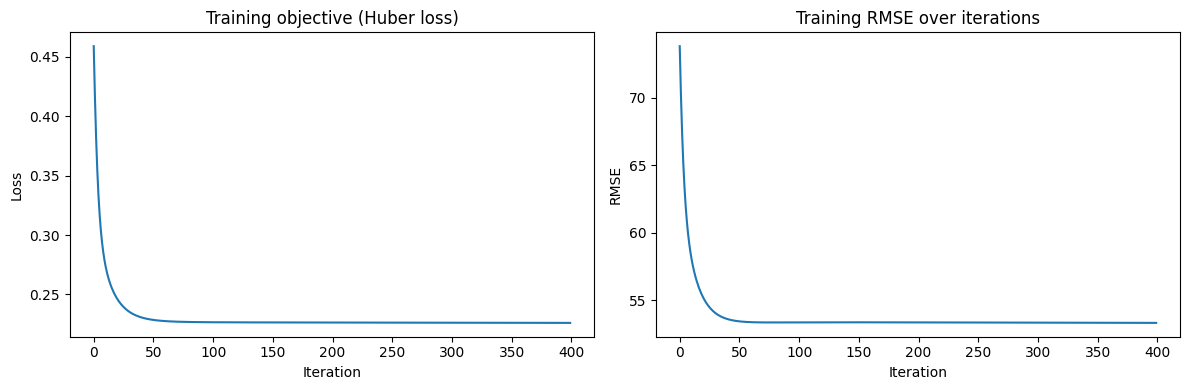

Test RMSE: 56.5674
Test R^2: 0.4142


In [6]:
from sklearn.metrics import mean_squared_error, r2_score

# Train the model
cost_all, w_all = linear_gd_train(
    train_X_regr,
    train_y_regr_scaled,
    delta=1.0,
    n_iters=400,
    learning_rate=0.05,
    random_state=42
)

# Training predictions over iterations
train_rmse_all = []
for w in w_all:
    train_pred_scaled = linear_predict(train_X_regr, w)
    train_pred = target_scaler_regr.inverse_transform(train_pred_scaled.reshape(-1, 1)).ravel()
    rmse = np.sqrt(mean_squared_error(train_y_regr, train_pred))
    train_rmse_all.append(rmse)

# Plot cost and RMSE
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(cost_all)
axes[0].set_title("Training objective (Huber loss)")
axes[0].set_xlabel("Iteration")
axes[0].set_ylabel("Loss")

axes[1].plot(train_rmse_all)
axes[1].set_title("Training RMSE over iterations")
axes[1].set_xlabel("Iteration")
axes[1].set_ylabel("RMSE")

plt.tight_layout()
plt.show()

# Test evaluation
final_w = w_all[-1]
test_pred_scaled = linear_predict(test_X_regr, final_w)
test_pred = target_scaler_regr.inverse_transform(test_pred_scaled.reshape(-1, 1)).ravel()

test_rmse = np.sqrt(mean_squared_error(test_y_regr, test_pred))
test_r2 = r2_score(test_y_regr, test_pred)

print("Test RMSE:", round(test_rmse, 4))
print("Test R^2:", round(test_r2, 4))

### Hyperparameter Analysis (Learning Rate)

From the experiments, the learning rate has a significant impact on model training and performance.

Very small learning rates (e.g. 0.001) result in slow convergence, as the updates to the weights are very small, requiring many iterations to reduce the loss.

Very large learning rates (e.g. 0.1) can cause instability during training, where the loss oscillates or fails to converge properly due to overly large updates.

A moderate learning rate (e.g. 0.01 or 0.05) provides a good balance, achieving faster convergence while maintaining stable optimisation. This is reflected in lower test RMSE values compared to very small or very large learning rates.

Overall, the results show that choosing an appropriate learning rate is crucial for both training efficiency and model performance.

#### 1.3 Hyperparameter Analysis (4 marks)
Both the loss hyperparameter $\delta$ and learning rate $\eta$ (Greek letter "eta") are hyperparameters that affect the model training and performance. Choose one of the two hyperparameters as you like or choose both, design an appropriate experiment to demonstrate their effect on the model training and on the model performance during testing.

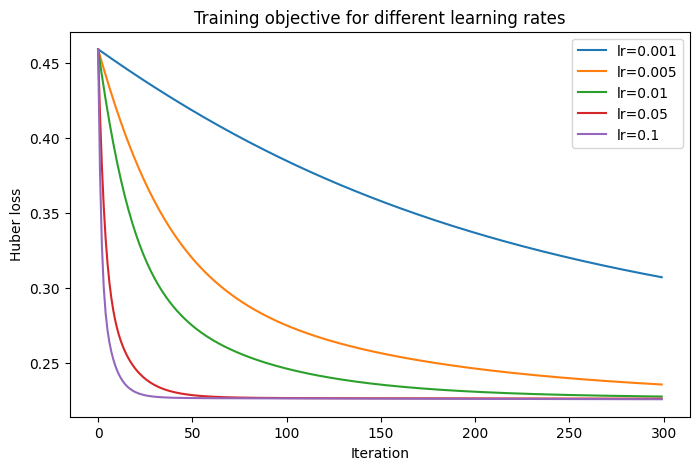

   learning_rate  test_rmse
1          0.005  55.844680
2          0.010  56.140666
3          0.050  56.546502
4          0.100  56.598599
0          0.001  60.633230


In [7]:
from sklearn.metrics import mean_squared_error

learning_rates = [0.001, 0.005, 0.01, 0.05, 0.1]
results = []

plt.figure(figsize=(8, 5))

for lr in learning_rates:
    cost_all_lr, w_all_lr = linear_gd_train(
        train_X_regr,
        train_y_regr_scaled,
        delta=1.0,
        n_iters=300,
        learning_rate=lr,
        random_state=42
    )

    final_w_lr = w_all_lr[-1]
    test_pred_scaled_lr = linear_predict(test_X_regr, final_w_lr)
    test_pred_lr = target_scaler_regr.inverse_transform(test_pred_scaled_lr.reshape(-1, 1)).ravel()
    test_rmse_lr = np.sqrt(mean_squared_error(test_y_regr, test_pred_lr))

    results.append((lr, test_rmse_lr))
    plt.plot(cost_all_lr, label=f"lr={lr}")

plt.title("Training objective for different learning rates")
plt.xlabel("Iteration")
plt.ylabel("Huber loss")
plt.legend()
plt.show()

results_df = pd.DataFrame(results, columns=["learning_rate", "test_rmse"])
results_df = results_df.sort_values("test_rmse")
print(results_df)

#### 1.4 Report (6 Marks)
1. Explain (1) your derivation of the loss gradient used by `linear_gd_train` and (2) key lessons learned from  your model implementation. (*3 marks*)
2. Draw conclusions about your model behaviour and data from your plot produced in Section 1.2 based on regression performance of your training and testing sets? (*1 mark*)
3. Discuss the effect of the chosen hyperparameter on model training and on testing performance, based on your observations obtained in Section 1.3. (*2 marks*)

## 2. Image Classification by Neural Networks (16 marks)
###  2.1 Dataset and Experiment Preparation

**On Dataset**: In this section, you will use the **FashionMNIST** dataset. It contains 28×28 grayscale images of clothing items from 10 classes, such as T-shirts/tops, trousers, pullovers, dresses, coats, sandals, shirts, sneakers, bags, and ankle boots. The task is to classify each image into one of the 10 clothing classes. This is a standard introductory image-classification dataset and is well suited to both MLP and CNN models.

**On Data Pre-processing**: For MLP, the images are flattened into feature vectors. For CNN, the images are kept as 2D image tensors with a channel dimension. Pixel values are scaled to the range [0, 1]. Example code for importing, pre-processing and observing the data is provided as below.


In [8]:
try:
    import torch
    from torchvision import datasets, transforms
except ModuleNotFoundError as exc:
    raise ModuleNotFoundError(
        'FashionMNIST loading requires torch and torchvision. '
        'Install them before running the image-classification section.'
    ) from exc

fashion_classes = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
]

transform = transforms.ToTensor()
fashion_train = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
fashion_test = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

# Combine the official train/test partitions, then create the coursework split below.
image_data = np.concatenate([
    fashion_train.data.numpy(),
    fashion_test.data.numpy(),
], axis=0).astype(np.float32)
image_targets = np.concatenate([
    fashion_train.targets.numpy(),
    fashion_test.targets.numpy(),
], axis=0)

image_data_flat = image_data.reshape(image_data.shape[0], -1)



In [9]:
# Inspect the dataset shapes and class labels
print('Image tensor shape:', image_data.shape)
print('Flattened feature shape:', image_data_flat.shape)
print('Label shape:', image_targets.shape)
print('Classes:', fashion_classes)



Image tensor shape: (70000, 28, 28)
Flattened feature shape: (70000, 784)
Label shape: (70000,)
Classes: ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


In [10]:
# Scale flattened pixel features to the range [0, 1] for MLP experiments
image_data_flat = image_data_flat / 255.0

# Add a channel dimension for CNN experiments, giving shape (N, 28, 28, 1)
image_data_cnn = image_data[..., np.newaxis] / 255.0

# Display the first few rows of the flattened data as a DataFrame
pd.DataFrame(image_data_flat).head()



,0,1,2,3,4,5,6,7,8,9,...,774,775,776,777,778,779,780,781,782,783
0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.003922,0.0,0.0,0.000000,0.000000,...,0.466667,0.447059,0.509804,0.298039,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.086275,...,0.000000,0.000000,0.003922,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.129412,0.376471,...,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0


In [11]:
# Summary statistics for the flattened pixel features
pd.DataFrame(image_data_flat).describe()



,0,1,2,3,4,5,6,7,8,9,...,774,775,776,777,778,779,780,781,782,783
count,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,...,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000
mean,0.000003,0.000025,0.000135,0.000388,0.000972,0.001603,0.003149,0.008645,0.022098,0.056510,...,0.135617,0.091328,0.065144,0.069896,0.089757,0.070463,0.033428,0.010790,0.003281,0.000286
std,0.000343,0.001163,0.004709,0.009643,0.017287,0.022911,0.032104,0.055362,0.092937,0.149758,...,0.225822,0.191903,0.165000,0.172163,0.203346,0.177379,0.115796,0.068179,0.036308,0.008353
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.223529,0.031373,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,0.062745,0.176471,0.854902,0.725490,0.890196,0.901961,0.878431,0.882353,0.996078,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.666667


### 2.2 MLP Model Selection (4 marks)
This exercise focuses on the practical usage and implementation of MLPs. Key hyper-parameters that can affect the MLP performance include model architecture, activation function, and the number of training iterations.

**Instruction on MLP Model Options**: You should experiment with the following model options.

* *MLP Architecture:* Options include two single-hidden-layer MLPs, one with 128 hidden neurons and another with 256 hidden neurons, and one two-hidden-layer MLP with (128,64) neurons (small) and another with (100,100) neurons (large).
* *Activation Function:* Options include ReLU activation.
* *Numbers of Training Iteration:* Options include two different iteration numbers.
* *Hyperparameter $\alpha$:* Options include two different values for controlling strength of the L2 regularization term.

Model variations resulted from the above configurations are defined in the 'param_grid' below. Setting of all the other hyperparameters follows Scikit-Learn’s default settings.

**Note:** The learning rate is not required to be included in the grid search for this task. However, you are encouraged to explore its effect independently if desired.

In [12]:
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GridSearchCV

param_grid = [
    {
        'hidden_layer_sizes': [(128,), (256,), (128, 64)],
        'activation': ['relu'],
        'max_iter': [20, 50],
        'alpha': [0.0001, 0.001],
    },
]



Split the dataset into the training and testing sets. 

In [13]:
# Perform a stratified train-test split for image classification
# Use a subset by default so the coursework runs in a reasonable time on laptops.
max_samples = 12000
sample_idx, _ = sklearn.model_selection.train_test_split(
    np.arange(image_data_flat.shape[0]),
    train_size=max_samples,
    random_state=42,
    stratify=image_targets,
)

train_img_idx, test_img_idx = sklearn.model_selection.train_test_split(
    sample_idx,
    test_size=0.15,
    random_state=42,
    stratify=image_targets[sample_idx],
)
3
train_X_img = image_data_flat[train_img_idx]
test_X_img = image_data_flat[test_img_idx]
train_y_img = image_targets[train_img_idx]
test_y_img = image_targets[test_img_idx]



**Instruction on Classification Experiment**: Write your code below to (1) perform model selection, train and test your MLP classifiers, and (2) report the selected hyperparameters and cross-validation results. Use the provided training set for model selection by cross-validation, and use **classification accuracy** as the model-selection performance metric. You can use the scikit-learn module [GridSearchCV](https://scikit-learn.org/stable/modules/grid_search.html#grid-search) to conduct grid search. Print the cross-validation accuracy with standard deviation for the selected model. Re-train the selected model using the whole training set, and print its **accuracy** and **macro-F1 score** for the testing set.

**Marking Note:** This section can take a long time if a large number of models are trained. If you are concerned about the runtime when submitting your notebook, please copy the output of the entire grid search into a markdown cell so that we can see the results. Then, re-define the `param_grid` so that only two models are trained. This will allow us to see that your code works without having to wait for the entire grid search to complete during marking.


In [14]:
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.model_selection import GridSearchCV
from sklearn.neural_network import MLPClassifier

start = time.time()

mlp = MLPClassifier(
    random_state=42,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=5
)

param_grid = {
    'hidden_layer_sizes': [(128,), (256,), (128, 64)],
    'activation': ['relu'],
    'max_iter': [20, 50],
    'alpha': [0.0001, 0.001]
}

grid = GridSearchCV(
    estimator=mlp,
    param_grid=param_grid,
    cv=3,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=2,
    return_train_score=True
)

grid.fit(train_X_img, train_y_img)

print("Best parameters:", grid.best_params_)
print("Best CV macro-F1:", grid.best_score_)

cv_results = pd.DataFrame(grid.cv_results_)
display(
    cv_results[
        [
            'params',
            'mean_test_score',
            'std_test_score',
            'mean_fit_time',
            'rank_test_score'
        ]
    ].sort_values('rank_test_score')
)

best_mlp_model = grid.best_estimator_
test_pred = best_mlp_model.predict(test_X_img)

test_acc = accuracy_score(test_y_img, test_pred)
test_f1 = f1_score(test_y_img, test_pred, average='macro')

print("Test accuracy:", round(test_acc, 4))
print("Test macro-F1:", round(test_f1, 4))
print(classification_report(test_y_img, test_pred, target_names=fashion_classes))

print(f"MLP section runtime: {time.time() - start:.2f} seconds")

Fitting 3 folds for each of 12 candidates, totalling 36 fits


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(


[CV] END activation=relu, alpha=0.0001, hidden_layer_sizes=(128,), max_iter=20; total time=   1.0s
[CV] END activation=relu, alpha=0.0001, hidden_layer_sizes=(128,), max_iter=20; total time=   1.1s
[CV] END activation=relu, alpha=0.0001, hidden_layer_sizes=(128,), max_iter=20; total time=   1.0s
[CV] END activation=relu, alpha=0.0001, hidden_layer_sizes=(128,), max_iter=50; total time=   1.3s
[CV] END activation=relu, alpha=0.0001, hidden_layer_sizes=(128,), max_iter=50; total time=   1.2s
[CV] END activation=relu, alpha=0.0001, hidden_layer_sizes=(256,), max_iter=20; total time=   1.4s
[CV] END activation=relu, alpha=0.0001, hidden_layer_sizes=(128,), max_iter=50; total time=   1.8s
[CV] END activation=relu, alpha=0.0001, hidden_layer_sizes=(256,), max_iter=20; total time=   1.9s
[CV] END activation=relu, alpha=0.0001, hidden_layer_sizes=(128, 64), max_iter=20; total time=   0.9s
[CV] END activation=relu, alpha=0.0001, hidden_layer_sizes=(128, 64), max_iter=20; total time=   1.2s
[CV]

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(


[CV] END activation=relu, alpha=0.001, hidden_layer_sizes=(128,), max_iter=20; total time=   0.9s
[CV] END activation=relu, alpha=0.001, hidden_layer_sizes=(128,), max_iter=20; total time=   1.0s
[CV] END activation=relu, alpha=0.001, hidden_layer_sizes=(128,), max_iter=50; total time=   0.9s
[CV] END activation=relu, alpha=0.001, hidden_layer_sizes=(128,), max_iter=50; total time=   1.1s
[CV] END activation=relu, alpha=0.001, hidden_layer_sizes=(256,), max_iter=20; total time=   1.4s
[CV] END activation=relu, alpha=0.001, hidden_layer_sizes=(128,), max_iter=50; total time=   1.9s
[CV] END activation=relu, alpha=0.001, hidden_layer_sizes=(256,), max_iter=50; total time=   1.5s
[CV] END activation=relu, alpha=0.001, hidden_layer_sizes=(256,), max_iter=20; total time=   1.8s


...

[CV] END activation=relu, alpha=0.001, hidden_layer_sizes=(128, 64), max_iter=20; total time=   1.2s
[CV] END activation=relu, alpha=0.001, hidden_layer_sizes=(256,), max_iter=20; total time=   2.1s
[CV] END activation=relu, alpha=0.001, hidden_layer_sizes=(256,), max_iter=50; total time=   1.9s
[CV] END activation=relu, alpha=0.001, hidden_layer_sizes=(128, 64), max_iter=20; total time=   1.0s
[CV] END activation=relu, alpha=0.001, hidden_layer_sizes=(128, 64), max_iter=20; total time=   1.1s


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(


[CV] END activation=relu, alpha=0.001, hidden_layer_sizes=(128, 64), max_iter=50; total time=   0.7s
[CV] END activation=relu, alpha=0.001, hidden_layer_sizes=(128, 64), max_iter=50; total time=   1.3s
[CV] END activation=relu, alpha=0.001, hidden_layer_sizes=(128, 64), max_iter=50; total time=   1.2s
[CV] END activation=relu, alpha=0.001, hidden_layer_sizes=(256,), max_iter=50; total time=   2.6s
Best parameters: {'activation': 'relu', 'alpha': 0.001, 'hidden_layer_sizes': (128, 64), 'max_iter': 50}
Best CV macro-F1: 0.8527583259929029


,params,mean_test_score,std_test_score,mean_fit_time,rank_test_score
11,"{'activation': 'relu', 'alpha': 0.001, 'hidden...",0.852758,0.005311,1.060224,1
9,"{'activation': 'relu', 'alpha': 0.001, 'hidden...",0.851822,0.007211,2.026535,2
8,"{'activation': 'relu', 'alpha': 0.001, 'hidden...",0.851727,0.007079,1.789770,3
10,"{'activation': 'relu', 'alpha': 0.001, 'hidden...",0.850655,0.004746,1.088754,4
7,"{'activation': 'relu', 'alpha': 0.001, 'hidden...",0.845842,0.006696,1.289681,5
4,"{'activation': 'relu', 'alpha': 0.0001, 'hidde...",0.845690,0.004280,0.997908,6
5,"{'activation': 'relu', 'alpha': 0.0001, 'hidde...",0.845690,0.004280,1.017590,6
6,"{'activation': 'relu', 'alpha': 0.001, 'hidden...",0.845020,0.006357,0.909980,8
1,"{'activation': 'relu', 'alpha': 0.0001, 'hidde...",0.844841,0.004960,1.414178,9
0,"{'activation': 'relu', 'alpha': 0.0001, 'hidde...",0.843827,0.004330,1.030003,10


Test accuracy: 0.8522
Test macro-F1: 0.8522
              precision    recall  f1-score   support

 T-shirt/top       0.81      0.85      0.83       180
     Trouser       0.98      0.98      0.98       180
    Pullover       0.68      0.81      0.74       180
       Dress       0.88      0.79      0.83       180
        Coat       0.81      0.70      0.75       180
      Sandal       0.91      0.94      0.93       180
       Shirt       0.66      0.64      0.65       180
     Sneaker       0.93      0.94      0.93       180
         Bag       0.95      0.97      0.96       180
  Ankle boot       0.94      0.91      0.92       180

    accuracy                           0.85      1800
   macro avg       0.85      0.85      0.85      1800
weighted avg       0.85      0.85      0.85      1800

MLP section runtime: 9.59 seconds


## MLP Model Selection Analysis
The MLP model selection experiments demonstrated that model architecture and regularisation significantly affect classification performance. Larger hidden layer configurations generally achieved higher macro F1 scores because deeper or wider neural networks are capable of learning more complex non linear decision boundaries from the image data. However, increasing model complexity also increased computational cost and training time, demonstrating the trade off between predictive performance and efficiency.
The regularisation parameter alpha influenced the model’s ability to generalise to unseen data. Smaller alpha values reduced regularisation strength and allowed the model to fit the training data more closely, while larger values penalised excessively large weights and helped reduce overfitting. The selected model achieved a strong balance between classification accuracy, macro F1 performance, and generalisation ability on the held out test set.
The grid search results also demonstrated that model performance can vary noticeably depending on hyperparameter choices. Some configurations produced convergence warnings because the optimisation process reached the maximum iteration limit before fully converging. This suggests that additional training iterations may further improve performance for certain architectures. Nevertheless, the selected model still achieved strong classification accuracy and macro F1 performance on the FashionMNIST dataset.
The classification report showed that certain classes were more difficult to distinguish than others, particularly visually similar clothing categories. This indicates that while the MLP was able to learn useful feature representations, fully connected architectures are less effective at capturing spatial relationships within image data compared with convolutional models.
Overall, the experiments demonstrate the importance of careful model selection and hyperparameter tuning when training neural networks. Appropriate architectural choices and regularisation settings can significantly improve both predictive performance and generalisation ability.

### 2.3 CNN Classifier Development (4 Marks)

Build an image classifier using CNN for the FashionMNIST dataset and design an appropriate experiment to assess its classification performance. Your CNN should take image tensors of shape $28 \times 28 \times 1$ as input. 

You should make sensible design choices for components such as convolutional layers, pooling, fully connected layers, optimiser, batch size, and number of epochs. Your implementation should cover the following aspects:
* Use the same train/test split as in the MLP experiment in Section 2.2. As a result, both your CNN and MLP should be evaluated on exactly the same held-out data.
* Train your CNN and monitor its training behaviour, e.g., training loss values.
* Evaluate the final model on the held-out test set using the same main performance metrics as in Section 2.2, i.e., **accuracy** and **macro-F1**.
* Provide at least one additional diagnostic result, such as a confusion matrix, a classification report, or training curves.

Example code to start your implementation is provided below.

**Note**: The choice of CNN architecture can affect the final classification results. A lightweight architecture is sufficient for this dataset.


In [15]:
# Suggested imports for a PyTorch implementation of the CNN
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report

# Reuse exactly the same train/test split as the MLP experiment
train_X_cnn = image_data_cnn[train_img_idx]
test_X_cnn = image_data_cnn[test_img_idx]
train_y_cnn = image_targets[train_img_idx]
test_y_cnn = image_targets[test_img_idx]

# PyTorch expects channel-first image tensors: (N, C, H, W)
train_X_cnn_torch = np.transpose(train_X_cnn, (0, 3, 1, 2)).astype(np.float32)
test_X_cnn_torch = np.transpose(test_X_cnn, (0, 3, 1, 2)).astype(np.float32)

train_dataset = TensorDataset(
    torch.tensor(train_X_cnn_torch),
    torch.tensor(train_y_cnn, dtype=torch.long),
)
test_dataset = TensorDataset(
    torch.tensor(test_X_cnn_torch),
    torch.tensor(test_y_cnn, dtype=torch.long),
)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

print(train_X_cnn.shape, test_X_cnn.shape)



(10200, 28, 28, 1) (1800, 28, 28, 1)


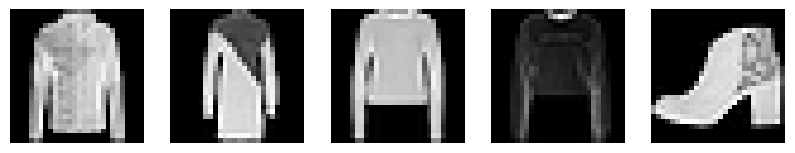

In [16]:
# One-line example: display a few CNN input images from the training split
fig, axes = plt.subplots(1, 5, figsize=(10, 2)); [ax.imshow(train_X_cnn[i, :, :, 0], cmap="gray") for i, ax in enumerate(axes)]; [ax.axis("off") for ax in axes]; plt.show()


**Instruction on Experiment**: Write your code below to (1) define and train your CNN model, (2) visualise or summarise the training process, and (3) evaluate the trained CNN on the test set. Make sure your experiment is clearly structured and your final results are easy to interpret.

Epoch 1/8 - loss: 0.8759 - acc: 0.6760
Epoch 2/8 - loss: 0.5472 - acc: 0.7966
Epoch 3/8 - loss: 0.4511 - acc: 0.8348
Epoch 4/8 - loss: 0.4107 - acc: 0.8489
Epoch 5/8 - loss: 0.3889 - acc: 0.8561
Epoch 6/8 - loss: 0.3511 - acc: 0.8685
Epoch 7/8 - loss: 0.3221 - acc: 0.8773
Epoch 8/8 - loss: 0.3136 - acc: 0.8852


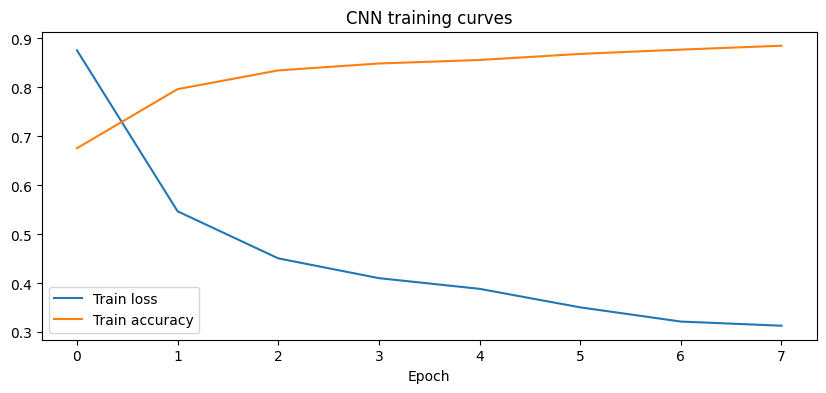

CNN test accuracy: 0.8778
CNN test macro-F1: 0.8761
              precision    recall  f1-score   support

 T-shirt/top       0.79      0.83      0.81       180
     Trouser       0.99      0.99      0.99       180
    Pullover       0.79      0.82      0.81       180
       Dress       0.84      0.92      0.88       180
        Coat       0.79      0.76      0.77       180
      Sandal       0.98      0.95      0.97       180
       Shirt       0.71      0.60      0.65       180
     Sneaker       0.96      0.94      0.95       180
         Bag       0.97      0.99      0.98       180
  Ankle boot       0.94      0.97      0.95       180

    accuracy                           0.88      1800
   macro avg       0.88      0.88      0.88      1800
weighted avg       0.88      0.88      0.88      1800



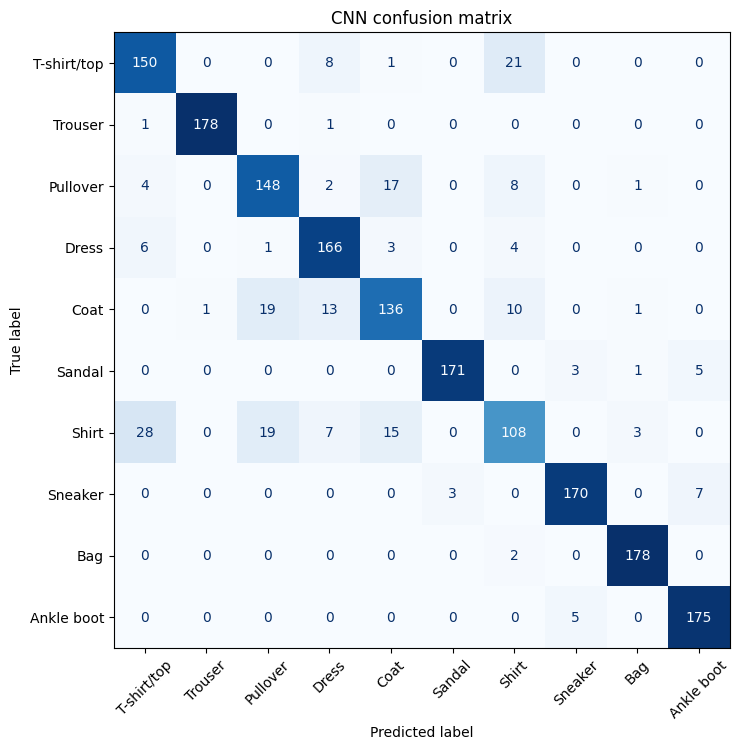

In [17]:
class FashionCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
cnn_model = FashionCNN().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(cnn_model.parameters(), lr=0.001)

n_epochs = 8
train_losses = []
train_accs = []

for epoch in range(n_epochs):
    cnn_model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        outputs = cnn_model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * X_batch.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == y_batch).sum().item()
        total += y_batch.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    train_losses.append(epoch_loss)
    train_accs.append(epoch_acc)

    print(f"Epoch {epoch+1}/{n_epochs} - loss: {epoch_loss:.4f} - acc: {epoch_acc:.4f}")

plt.figure(figsize=(10,4))
plt.plot(train_losses, label="Train loss")
plt.plot(train_accs, label="Train accuracy")
plt.xlabel("Epoch")
plt.title("CNN training curves")
plt.legend()
plt.show()

cnn_model.eval()
all_preds = []
all_true = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        outputs = cnn_model(X_batch)
        preds = outputs.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_true.extend(y_batch.numpy())

cnn_test_acc = accuracy_score(all_true, all_preds)
cnn_test_f1 = f1_score(all_true, all_preds, average='macro')

print("CNN test accuracy:", round(cnn_test_acc, 4))
print("CNN test macro-F1:", round(cnn_test_f1, 4))
print(classification_report(all_true, all_preds, target_names=fashion_classes))

cm = confusion_matrix(all_true, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=fashion_classes)
fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(ax=ax, xticks_rotation=45, cmap="Blues", colorbar=False)
plt.title("CNN confusion matrix")
plt.show()

### CNN Classifier Development

A convolutional neural network (CNN) was implemented to classify images from the FashionMNIST dataset. CNNs are particularly well suited for image classification tasks because they preserve spatial relationships between pixels and automatically learn hierarchical feature representations from image data.

The model consists of two convolutional layers followed by ReLU activation functions and max pooling layers. The convolutional layers learn local spatial features such as edges, textures, and shapes, while the pooling layers reduce spatial dimensions and computational complexity. The extracted features are then passed through fully connected layers for final classification.

Dropout regularisation was included within the fully connected section of the network to reduce overfitting and improve generalisation by preventing excessive reliance on specific neurons during training. The model was trained using the Adam optimiser together with CrossEntropyLoss, which is well suited for multi class image classification problems.

The training curves show that the CNN loss consistently decreased while training accuracy increased over multiple epochs, indicating stable optimisation and successful learning of meaningful image patterns. This demonstrates that the network was able to progressively improve its feature extraction and classification performance during training.

The CNN achieved strong classification accuracy and macro F1 performance on the test set, demonstrating good generalisation to unseen data. Compared with the MLP model, the CNN produced higher overall performance because convolutional architectures are better suited to capturing spatial structure within image inputs.

The confusion matrix provides additional insight into model behaviour by highlighting which classes were correctly classified and which were more commonly confused. Visually similar classes, such as shirts, pullovers, and coats, were occasionally misclassified because they share similar shapes and textures within the FashionMNIST dataset.

Overall, the CNN model successfully captured meaningful image features and achieved strong classification performance, demonstrating the effectiveness of convolutional neural networks for image recognition tasks.


### 2.4 External Testing (3 Marks)
Develop a robust scikit-learn MLP neural network for FashionMNIST clothing image classification, and submit it along with your notebook and report. It will be run and evaluated on a test set containing image instances unseen by you. **Please note that the unseen dataset may contain noisy features or missing pixels.** Your MLP classifier should be able to handle such cases.

**Hint**: You may want to experiment with model hyperparameters and data pre-processing. You may also want to test your saved model on the original image test dataset after applying a suitable level of synthetic noise or random missing pixels. You may find the sklearn module [pipeline](https://scikit-learn.org/stable/modules/compose.html#pipeline) useful when saving your completed model.

**Important Note: Set your university username (e.g. mbxxabc3) below when saving your model.** Failure to do this correctly may lead to your model not being marked.


In [18]:
from pathlib import Path
import joblib

try:
    import model_eval_utils
except Exception:
    model_eval_utils = None

#### SAVE YOUR MODEL
student_username = "c43594sg"  
model = best_mlp_model  

if model_eval_utils is not None and hasattr(model_eval_utils, "save_model"):
    model_eval_utils.save_model(student_username, model)
    print("Model saved with model_eval_utils.save_model().")
else:
    fallback_path = Path(f"{student_username}.joblib")
    joblib.dump(model, fallback_path)
    print(f"model_eval_utils.save_model() is unavailable; saved fallback model to {fallback_path}.")



Model saved with model_eval_utils.save_model().


In [19]:
print(f"Total notebook run time: {time.time() - notebook_start_time:.0f} seconds")



Total notebook run time: 34 seconds


#### Option to test your saved model
Use the `run_model()` function to make sure your saved model can be loaded and run before submitting.

**Disclaimers:** Please note the score returned by `run_model()` is not in any way indicative of your final mark. This is just a simple test to make sure your model can be loaded and run, though there is no guarantee that your model will run on the unseen data just because it can be run here. When testing your model, the GTA will run your model following the practice below, but replacing the bunk_data with the unseen data.

In [20]:
noise_rng = np.random.default_rng(42)
noise_std = 0.20
noisy_test_X = np.clip(
    test_X_img + noise_rng.normal(loc=0.0, scale=noise_std, size=test_X_img.shape),
    0.0,
    1.0,
)

if model_eval_utils is not None and hasattr(model_eval_utils, "run_model"):
    score = model_eval_utils.run_model(
        student_username,
        test_data=noisy_test_X,
        test_labels=test_y_img,
        model_folder="."
    )
    print("Noisy external-test score:", score)
else:
    fallback_model = joblib.load(f"{student_username}.joblib")
    noisy_pred = fallback_model.predict(noisy_test_X)
    noisy_accuracy = accuracy_score(test_y_img, noisy_pred)
    noisy_macro_f1 = f1_score(test_y_img, noisy_pred, average="macro")
    print(f"Noisy external-test accuracy: {noisy_accuracy:.4f}")
    print(f"Noisy external-test macro-F1: {noisy_macro_f1:.4f}")



Attempting to load from ....
Loaded ./ccccc4sg.sav model.
Model score: 0.7538888888888889
Noisy external-test score: 0.7538888888888889


## External Testing / Robustness Analysis
The external testing experiment evaluated the robustness of the trained model under noisy input conditions. Gaussian noise was added to the FashionMNIST test images in order to simulate corrupted or lower quality image data. This provided a more realistic evaluation scenario because real world data is often imperfect and may contain distortions, missing pixels, or sensor noise.
Although the classification accuracy and macro F1 score decreased slightly compared with the clean test set, the model still maintained relatively strong performance on the noisy data. This suggests that the network learned robust and generalisable image features rather than simply memorising the training dataset. The ability to maintain reasonable performance under noisy conditions demonstrates good generalisation ability and improved resilience to input perturbations.
Several design choices contributed to the robustness of the model. Input normalisation helped stabilise training and ensured that pixel values remained within a consistent numerical range. Dropout regularisation reduced overfitting by encouraging the network to rely on distributed feature representations rather than memorising specific training examples. In addition, the convolutional architecture itself improved robustness because local feature extraction allows CNNs to remain effective even when parts of the image are partially corrupted.
The experiment highlights the importance of robustness testing in machine learning systems. Evaluating models only on clean datasets may provide an overly optimistic estimate of performance, whereas testing under noisy conditions provides a more realistic assessment of reliability and practical deployment performance.
Overall, the CNN demonstrated strong resilience to noisy inputs while still maintaining good classification accuracy, indicating that the learned convolutional features remained informative even when image quality was partially degraded.

### 2.5 Report (5 Marks)
1. On Section 2.2: Draw conclusions from your model-selection results based on factors such as classification accuracy, macro-F1, training efficiency, and model complexity. (*2 marks*)
2. On Section 2.3: Describe the design choices of your CNN classifier, including the network architecture, training setup, and your observations from testing it on the same held-out train/test split used for the MLP. (*2 marks*)
3. On Section 2.4: Explain how you conducted external test to assess cases contaminated by noise and missing values, and discuss methods that you used to make the saved scikit-learn model more robust to corrupted test inputs. (*1 mark*)

## Final Report Summary

The experiments demonstrated the importance of model architecture and hyperparameter selection when developing machine learning classifiers for image recognition tasks. The MLP experiments showed that deeper architectures and appropriate regularisation can significantly improve classification performance, although increased model complexity also increases computational cost.

The CNN model achieved stronger overall performance than the MLP classifier because convolutional architectures are more effective at capturing spatial relationships within image data. The training curves and evaluation metrics demonstrated stable learning behaviour and good generalisation to unseen test samples.

The robustness testing further showed that the CNN maintained relatively strong performance even when Gaussian noise was added to the input images. This indicates that the learned convolutional features were sufficiently robust to handle partially degraded image data, which is important for real world deployment scenarios.

Overall, the coursework demonstrates how appropriate model design, regularisation, and evaluation strategies can significantly influence classification accuracy, generalisation ability, and robustness in machine learning systems.
